title: "Week 4 (CS 418 @ UIC)"
jupyter: python3

<!-- slide 1 -->
# Week 4 Slide Deck {.course-title}

## Exploratory Analysis; Descriptive Stats

Jack Bandy
2026

---

<!-- slide 2 -->
# Exploratory Data Analysis {.course-title .photo-title data-state="photo-title" background-image="../assets/orange-line-stops-better/stop04-washington-wells-b.jpg" background-size="cover"}

CS 418 · Week 4 · 🟠 Washington/Wells 🟠

---

<!-- slide 3 -->
# Demo Content Slide

Placeholder content for Week 4.

- Exploratory analysis
- Descriptive statistics
- Initial data questions

---

<!-- slide 4 -->
# What is Exploratory Data Analysis? {.smaller}

- Exploratory Data Analysis (EDA) is the process of exploring and analyzing data to better understand it, discover patterns, identify potential issues, and determine the best approach for building predictive models.


- The main tools of exploratory data analysis are:
  - **Summary Statistics** (mean, median, spread, counts)
  - **Visualization** (histograms, box plots, scatter plots)

---

<!-- slide 5 -->
# Exploratory vs. Confirmatory {.smaller}

::: {.incremental}
- EDA was promoted by statistician **John Tukey** as a contrast to **confirmatory data analysis**, which is concerned with modeling and hypothesis testing.
- In EDA, there is **no hypothesis** and **no model**. We just want to gain intuition about the data.
:::

::: {.fragment style="font-size:0.8em; font-style:italic; margin-top:1em;"}
"Exploratory data analysis is an attitude, a state of flexibility, a willingness to look for those things that we believe are not there, as well as those we believe to be there." — Tukey
:::

---

<!-- slide 6 -->
# Why Exploratory Data Analysis matters?

::: {.incremental}
- Identify trends patterns 
- Discover relationship between variables
- Test underlying assumptions
- Ensure the data is suitable for further analysis
:::

---

<!-- slide 7 -->
# Before you model, understand your data {.smaller}

::: {.incremental}
- Before you run any analysis or build any machine learning system, **always understand your data**.
- If *you* can't identify a trend or make a prediction for your dataset, neither will an automated algorithm.
- Worth remembering as you hear stories of "superhuman" ML performance — it's possible, but it takes a long time, and it is not the norm.
- Exploration also gives you ideas for how to represent and clean your data better. The right pre-processing often matters more than which algorithm you pick.
:::

---

<!-- slide 8 -->
# Steps
- The steps of exploratory data analysis are:
  1. Data Collection and Loading (setting up your environment)
  2. Summary Statistics (*describe()* using polars)
  3. Handling anomalies (e.g missing data)
  4) Understanding the shape of the data 
  5) Detecting outliers
  6) Correlation Analysis

---

<!-- slide 9 -->
# Discovering and handling anomalies {.smaller}
This is one of the crucial steps in EDA, because if not handled properly can introduce bias.

- Categories:
  - Missing value (e.g nulls, N/A, NaN)
  - Duplicates (multiple rows with same values)
  - Incosistent formatig (e.g "yyyy/dd/mm" vs "mm/dd/yyyy")
  - Wrong data types (dates stored as strings, numbers stores as string)
  - Invalid values (e.g age = 350)
  - Structure issues (mixed units: miles vs km)

---

<!-- slide 10 -->
# Understanding your data with polars {.smaller}

The polars package has methods to explore the features in a dataframe:

- `df.shape` — the dimensions of the dataframe (number of rows, number of columns)
- `df.glimpse()` — name, type, and first values of each feature
- `df.null_count()` — how many missing values each feature has
- `df.describe()` — summary statistics (count, null count, mean, standard deviation, min/max, and quartiles) for each feature

```python
import polars as pl
df = pl.read_csv('ages.csv')
print(df.shape)
# (3, 2)
```

---

<!-- slide 11 -->
# Descriptive vs. Inferential Statistics {.smaller}

Statistics deals with the collection, analysis, interpretation, and presentation of data. There are two types of statistical analysis:

::: {.incremental}
- **Descriptive statistics** summarize data about a *sample* drawn from a population.
  - Measures of central tendency (mean, median, mode)
  - Measures of dispersion or spread (range, standard deviation, variance)
- **Inferential statistics** use information from the sample to draw conclusions about the population.
:::

::: {.fragment}
This week is about the first one.
:::

---

<!-- slide 12 -->
# Descriptive Statistics

::: {.incremental}
- Summarize and describe what's in the data.
- **Center:** Mean, median, mode.
- **Spread:** Maximum, Minimum, Range, Standard deviation, Variance.
- **Position:** Quartiles and percentiles.
:::

---

<!-- slide 13 -->
# Measures of Center

- **Mean** — the average of all the values.
- **Median** — the middle value of the sorted data.
- **Mode** — the most frequent value (can be more than one).

**Example** A = {7, 9, 9, 12, 13}

**Mean =** (7 + 9 + 9 + 12 + 13) / 5 = 10  
**Median =** 9  
**Mode =** 9

---

<!-- slide 14 -->
# Measures of Center

::: {style="font-size:0.6em; font-style:normal; color:#1f8a9b; font-weight:700; margin-top:-0.3em;"}
Using Python
:::

With a polars DataFrame, each measure is one method call:

- `df.mean()` — the mean of every column
- `df.median()` — the median of every column
- `df["grades"].mode()` — the mode (a Series method; there may be more than one)

---

<!-- slide 15 -->
# Measures of Spread

:::: {.columns}
::: {.column width="20%"}

<table style="border-collapse:collapse; margin:0.2em 26px 0 auto;">
<tr><td style="border:2px solid #f9461c; background:#f9461c; color:#fff; font-weight:bold; padding:6px 22px; text-align:center;">Grades</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">24</td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 30px; text-align:center;"><span style="display:inline-block; border:3px solid #1f2d3d; border-radius:50%; width:50px; height:50px; line-height:50px; font-weight:bold;">35</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">32</td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 30px; text-align:center;"><span style="display:inline-block; border:3px solid #1f2d3d; border-radius:50%; width:50px; height:50px; line-height:50px; font-weight:bold;">21</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">28</td></tr>
</table>

::: {style="font-size:0.5em; text-align:center; margin-top:0.6em; line-height:1.6;"}
[Maximum = 35]{style="color:#1f2d3d; font-weight:bold;"}<br>
[Minimum = 21]{style="color:#1f2d3d; font-weight:bold;"}
:::

:::
::: {.column width="80%"}

::: {style="font-size:0.82em;"}
**Maximum** — The largest value in the data set.

**Minimum** — The smallest value in the data set.

**Range** — How far the data stretches, end to end.
:::

::: {style="text-align:center; margin-top:1.2em;"}
$$\text{Range} = \text{Max} - \text{Min} = 35 - 21 = 14$$
:::

:::
::::

---

<!-- slide 16 -->
# Measures of Spread

:::: {.columns}
::: {.column width="20%"}

<table style="border-collapse:collapse; margin:0.2em 26px 0 auto;">
<tr><td style="border:2px solid #f9461c; background:#f9461c; color:#fff; font-weight:bold; padding:6px 22px; text-align:center;">Grades</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">24</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">35</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">32</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">21</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 30px; text-align:center;">28</td></tr>
</table>

::: {style="font-size:0.5em; text-align:right; margin-top:0.6em; line-height:1.6;"}
[Variance = 32.5]{style="color:#000000; font-weight:bold;"}<br>
[Standard Deviation ≈ 5.7]{style="color:#000000; font-weight:bold;"}
:::

:::
::: {.column width="80%"}

::: {style="font-size:0.82em;"}
**Standard deviation** — The typical distance from the mean, in the data's own units.

**Variance** — The variance of a dataset is the square of the standard deviation.

Mean $\bar{x} = 28$.
:::

::: {style="text-align:center; margin-top:1.2em;"}
$$\begin{aligned}
s^2 &= \frac{\sum (a_i-\bar{x})^2}{n-1} = \frac{130}{4} = 32.5 \\[6pt]
s &= \sqrt{32.5} \approx 5.7
\end{aligned}$$
:::

:::
::::

---

<!-- slide 17 -->
# Measures of Position 

:::: {.columns}

::: {.column width="32%"}
<table style="border-collapse:collapse; margin:0.4em auto 0;">
<tr><td style="border:2px solid #f9461c; background:#f9461c; color:#fff; font-weight:bold; padding:6px 24px; text-align:center;">Grades (sorted)</td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 24px; text-align:center;">21</td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 24px; text-align:center;"><span style="display:inline-block; border:3px solid #001E62; border-radius:50%; width:50px; height:50px; line-height:50px; color:#1f2d3d; font-weight:bold;">24</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 24px; text-align:center;"><span style="display:inline-block; border:3px solid #001E62; border-radius:50%; width:50px; height:50px; line-height:50px; color:#1f2d3d; font-weight:bold;">28</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:4px 24px; text-align:center;"><span style="display:inline-block; border:3px solid #001E62; border-radius:50%; width:50px; height:50px; line-height:50px; color:#1f2d3d; font-weight:bold;">32</span></td></tr>
<tr><td style="border:2px solid #f9461c; padding:6px 24px; text-align:center;">35</td></tr>
</table>
:::

::: {.column width="68%"}

::: {style="font-size:0.8em;"}
**Percentiles** divide a dataset into 100 equal parts such that n% of the data is less than or equal to the nth percentile.

**Quartiles** divide a dataset into quarters.

- First quartile (Q1) = 25% or less of the data.
- Second quartile (Q2) = 50% or less of the data / Median.
- Third quartile (Q3) = 75% or less of the data.
:::

<div style="text-align:center; margin-top:0.6em;">
<span style="display:inline-block; border:2px solid #001E62; border-radius:6px; padding:6px 18px; margin:0 6px; font-weight:bold; color:#1f2d3d;">Q1 = 24</span>
<span style="display:inline-block; border:2px solid #001E62; border-radius:6px; padding:6px 18px; margin:0 6px; font-weight:bold; color:#1f2d3d;">Q2 = 28</span>
<span style="display:inline-block; border:2px solid #001E62; border-radius:6px; padding:6px 18px; margin:0 6px; font-weight:bold; color:#1f2d3d;">Q3 = 32</span>
</div>
:::

::::

---

<!-- slide 18 -->
# The Five-Number Summary

::: {.incremental}
- The minimum, **Q1**, the median (**Q2**), **Q3**, and the maximum together form a set of descriptive statistics called the **five-number summary**.
- The **interquartile range (IQR)** is $Q3 - Q1$ — the range covered by the middle 50% of the data.
- These five numbers are exactly what a **box plot** draws.
:::

---

<!-- slide 19 -->
# Detecting Outliers {.smaller}

::: {.incremental}
- An **outlier** is a value much larger or much smaller than the rest of the data.
- The common rule: a point is an outlier if it falls more than **1.5 × IQR** below Q1 or above Q3.
  - Some implementations use 3 × IQR, or other cutoffs — the 1.5 rule is a convention, not a law.
- Box plots are useful for summarizing a distribution *and* for comparing several distributions side by side.
- Outliers are not automatically errors. Investigate before you delete.
:::

---

<!-- slide 20 -->
# Data Visualization {.section-header}

---

<!-- slide 21 -->
# Two Kinds of Visualization {.smaller}

::: {.incremental}
- **Data exploration visualization:** figuring out what is true. Fast, rough, for you.
- **Data presentation visualization:** convincing other people it is true. Polished, for an audience.
:::

::: {.fragment style="margin-top:1em;"}
This week is mostly the first kind.
:::

---

<!-- slide 22 -->
# Choosing a Plot: Quantitative Data {.smaller}

**Plots:** histograms, box plots, rug plots, smoothed interpolations (KDE — kernel density estimators)

::: {.incremental}
- **Histogram** — relative frequency of values; there's a tradeoff in choosing bin sizes.
- **Rug plot** — shows where the actual data points sit.
- **KDE plot** — a smoothed density estimate; there's a tradeoff in the "bandwidth" parameter.
:::

::: {.fragment style="margin-top:0.8em;"}
**Look for:** spread, shape, modes, gaps, outliers, unreasonable values.
:::

---

<!-- slide 23 -->
# Choosing a Plot: Categorical Data {.smaller}

**Plots:** bar plots, sorted by frequency or by the ordinal dimension

::: {.incremental}
- **Look for:** skew, frequent and rare categories, invalid categories.
- Consider grouping rare categories together and repeating the analysis.
- For **ordinal** data (e.g. education level: < 12th, HS, Trade, Some College, College), keep the natural order — don't sort bars shortest to tallest.
- **Dot plots** (Cleveland dot plots) make it easier to compare values than bars do.
:::

::: {.fragment style="font-size:0.85em; margin-top:0.6em;"}
Bar *width* has no meaning. Only length encodes the value.
:::

---

<!-- slide 24 -->
# Describing the Shape of Data {.smaller}

Many models assume features are **symmetric** and **unimodal**. Deviations can affect the validity of the model.

::: {.incremental}
- **Symmetric** — looks the same on the left and right sides.
- **Skewed** — one tail is longer than the other (right-skewed, left-skewed).
- **Unimodal** — a single mode (peak).
- **Multimodal** — multiple modes (peaks).
:::

::: {.fragment style="margin-top:0.8em;"}
Histograms are the tool for exploring shape.
:::

---

<!-- slide 25 -->
# Identifying Relationships {.smaller}

::: {.incremental}
- Features in a dataset are usually related to each other. **Linear** relationships are the simplest type.
- **Correlation** describes the *strength* and *direction* of a linear relationship between two features.
  - **Positive** correlation — one feature increases as the other increases.
  - **Negative** correlation — one feature decreases as the other increases.
- We explore relationships using **scatter plots**: positive correlation, negative correlation, or no linear correlation.
:::

---

<!-- slide 26 -->
# Three Scatter Plots

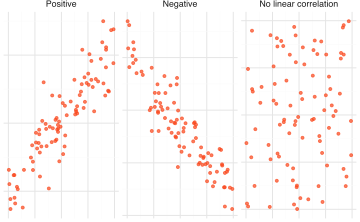

In [1]:
#| echo: false
#| fig-alt: 'Three scatter plots side by side: points trending upward (positive correlation), points trending downward (negative correlation), and points with no visible trend (no linear correlation)'
import numpy as np
import polars as pl
from plotnine import *

rng = np.random.default_rng(418)
x = rng.uniform(0, 10, 90)
kinds = ["Positive", "Negative", "No linear correlation"]
shapes = pl.DataFrame({
    "x": np.tile(x, 3),
    "y": np.concatenate([x + rng.normal(0, 1.5, 90),
                         -x + rng.normal(0, 1.5, 90),
                         rng.uniform(0, 10, 90)]),
    "kind": np.repeat(kinds, 90),
}).with_columns(pl.col("kind").cast(pl.Enum(kinds)))

(ggplot(shapes, aes("x", "y"))
 + geom_point(color="#f9461c", alpha=0.7, size=1.2)
 + facet_wrap("kind", scales="free_y")
 + theme_minimal()
 + theme(axis_title=element_blank(), axis_text=element_blank()))

---

<!-- slide 28 -->
# Correlation Coefficient {.smaller}

Pearson's correlation coefficient measures the linear relationship between two features $X$ and $Y$.

::: {.incremental}
- The value is always between **-1 and 1**.
- The sign gives the direction; the closer to -1 or 1, the **stronger** the relationship.
- A coefficient of **0** means there is no *linear* relationship — which is not the same as no relationship at all.
:::

---

<!-- slide 29 -->
# Setup: Chicago 'L' ridership, 2019 {.smaller}

Do the stations that are busy on weekdays stay busy on Saturdays?

In [2]:
#| echo: true
cta = pl.read_csv("../../datasets/cta-ridership/Station_Entries_-_Daily_Totals_20260527.csv",
                  ignore_errors=True)
cta = cta.with_columns(pl.col("rides").str.replace_all(",", "").cast(pl.Int64))
by_day = (cta.filter(pl.col("date").str.ends_with("2019"))
             .group_by("stationname", "daytype")
             .agg(pl.col("rides").mean()))
stations = by_day.pivot("daytype", index="stationname", values="rides")

::: {style="font-size:0.8em; margin-top:0.4em;"}
`daytype` is `W` for weekdays, `A` for Saturdays, `U` for Sundays and holidays.
:::

---

<!-- slide 30 -->
# Weekday vs. Saturday {.code-figure-slide}

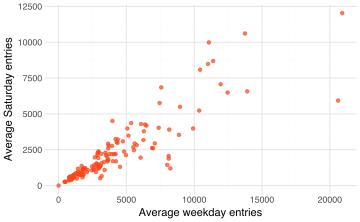

In [3]:
#| echo: true
#| fig-alt: "Scatter plot of 144 Chicago 'L' stations, average weekday entries on the x-axis against average Saturday entries on the y-axis, showing a strong upward linear trend"
(ggplot(stations, aes("W", "A"))
 + geom_point(color="#f9461c", alpha=0.7)
 + labs(x="Average weekday entries", y="Average Saturday entries")
 + theme_minimal())

---

<!-- slide 31 -->
# How strong is it?

In [4]:
#| echo: true
stations.select(pl.corr("W", "A")).item()

0.8792986245373241

::: {style="font-size:0.85em; margin-top:0.8em;"}
Strong and positive: busy stations are busy on both days. Not *perfect* — Loop stations serving commuters drop off far more on a Saturday than neighborhood stations do.
:::

---

<!-- slide 32 -->
# Putting It Together {.smaller}

**One-dimensional data**

- Summarize with summary statistics (mean, standard deviation, max, min, quartiles).
- Visualize the distribution with histograms and box plots.

**Two-dimensional data**

- Visualize the relationship with scatter plots.
- Measure the relationship by computing correlations.

**High-dimensional data**

- Create a **scatterplot matrix** showing all pairwise scatter plots.
- Create a **correlation matrix** showing all pairwise correlations.

---

<!-- slide 33 -->
# Sources {.sources}

1. GitHub source: <https://github.com/jackbandy/data-science-fun/blob/main/docs/slides/week4.qmd>.
1. Last modified and compiled July 27, 14:16h Central (Chicago) time.
2. Slides developed using materials from [Elena Zheleva](https://www.cs.uic.edu/~elena/) and [Gonzalo Bello Lander](https://cs.uic.edu/profiles/gonzalo-bello/), the Berkeley DS 100 team, Marine Carpuat, and Brian Ziebart.
3. Slide deck built with [Quarto](https://quarto.org/) revealjs.
4. Title font is Big Shoulders; Body font is [Libre Franklin](https://en.wikipedia.org/wiki/Franklin_Gothic#Libre_Franklin).